In [1]:
import sys
from pathlib import Path

# Add parent directory to path so we can import from src
parent_dir = Path().resolve().parent.parent
sys.path.insert(0, str(parent_dir))

import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg
from src.pt import BrenierGaussian
from src.geom import log_map_gaussian
# change to latex font
plt.rcParams['mathtext.fontset'] = 'cm'

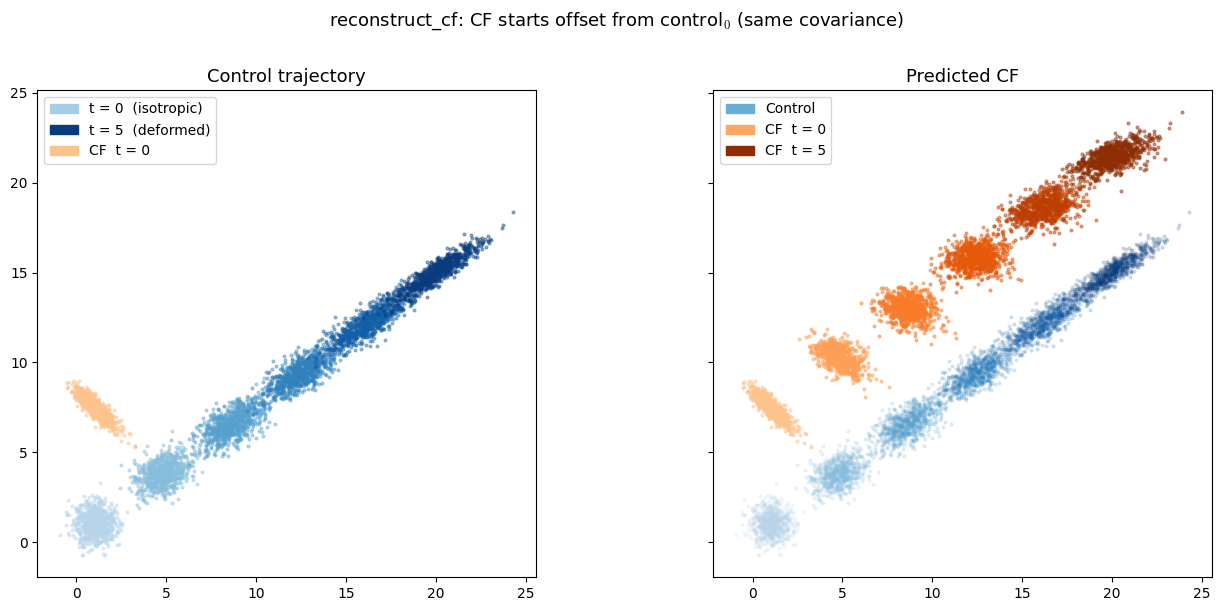

Control displacement : [18.99  14.001]
CF displacement      : [18.99  14.001]
Difference           : [ 0. -0.]

step             ctrl mean               CF mean
--------------------------------------------------
   0         [1.024 1.023]         [1.028 7.467]
   1         [4.813 3.838]       [ 4.816 10.282]
   2         [8.62  6.585]       [ 8.624 13.029]
   3       [12.41   9.384]       [12.414 15.828]
   4       [16.199 12.187]       [16.202 18.631]
   5       [20.015 15.024]       [20.018 21.468]


In [21]:
from src.cf_recon import reconstruct_cf
import matplotlib.cm as cm
from matplotlib.patches import Patch

np.random.seed(42)

# ── Control trajectory ────────────────────────────────────────────────────────
n_steps  = 5
n_samples = 800

mean_0 = np.array([1.0, 1.0])
mean_T = np.array([20.0, 15.0])

Sigma_0 = 0.35 * np.eye(2)                          # isotropic
Sigma_T = np.array([[1.4, 0.9], [0.9, 0.7]])        # elongated, tilted

control_samples = []
for i in range(n_steps + 1):
    alpha   = i / n_steps
    mean_i  = (1 - alpha) * mean_0 + alpha * mean_T
    Sigma_i = (1 - alpha) * Sigma_0 + alpha * Sigma_T
    control_samples.append(
        np.random.multivariate_normal(mean_i, Sigma_i, size=n_samples)
    )

# ── CF initial: same covariance as control[0], but offset mean ────────────────
cf_mean_0 = mean_0 + np.array([0.0, 6.5])           # shift upward
cf_sigma_0 = np.array([[0.35, -0.3], [-0.3, 0.35]]) 
# cf_sigma_0 = np.array([[0.1, -0.00], [-0.00, 0.1]])                         # smaller isotropic covariance
cf_0 = np.random.multivariate_normal(cf_mean_0, cf_sigma_0, size=n_samples)

# ── Reconstruct ───────────────────────────────────────────────────────────────
cf_curve = reconstruct_cf(control_samples, cf_0, n=n_steps, project=False)

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

blues   = cm.Blues
oranges = cm.Oranges

for ax in axes:
    ax.set_aspect('equal')

# left panel: control trajectory
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[0].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.4, rasterized=True)
# initial CF (orange)
axes[0].scatter(cf_0[:, 0], cf_0[:, 1], color=oranges(0.3), s=4, alpha=0.45, rasterized=True)
axes[0].set_title('Control trajectory', fontsize=13)
axes[0].legend(handles=[
    Patch(color=blues(0.35), label='t = 0  (isotropic)'),
    Patch(color=blues(0.95), label=f't = {n_steps}  (deformed)'),
    Patch(color=oranges(0.3), label='CF  t = 0'),
], loc='upper left', fontsize=10)
# plot initial CF as well

# right panel: control (faded) + CF (orange)
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[1].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.15, rasterized=True)
for i, m in enumerate(cf_curve):
    c = oranges(0.3 + 0.65 * i / n_steps)
    axes[1].scatter(m.locs[:, 0], m.locs[:, 1], color=c, s=4, alpha=0.45, rasterized=True)
axes[1].set_title(f'Predicted CF', fontsize=13)
axes[1].legend(handles=[
    Patch(color=blues(0.5),   label='Control'),
    Patch(color=oranges(0.4), label='CF  t = 0'),
    Patch(color=oranges(0.95),label=f'CF  t = {n_steps}'),
], loc='upper left', fontsize=10)

plt.suptitle('reconstruct_cf: CF starts offset from control$_0$ (same covariance)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Quantitative check: mean displacement should be approximately preserved ───
ctrl_displacement = control_samples[-1].mean(axis=0) - control_samples[0].mean(axis=0)
cf_displacement   = cf_curve[-1].locs.mean(axis=0)   - cf_curve[0].locs.mean(axis=0)
print(f"Control displacement : {ctrl_displacement.round(3)}")
print(f"CF displacement      : {cf_displacement.round(3)}")
print(f"Difference           : {(ctrl_displacement - cf_displacement).round(3)}")

print(f"\n{'step':>4}  {'ctrl mean':>20}  {'CF mean':>20}")
print('-' * 50)
for i, (s, m) in enumerate(zip(control_samples, cf_curve)):
    print(f"{i:>4}  {str(s.mean(axis=0).round(3)):>20}  {str(m.locs.mean(axis=0).round(3)):>20}")

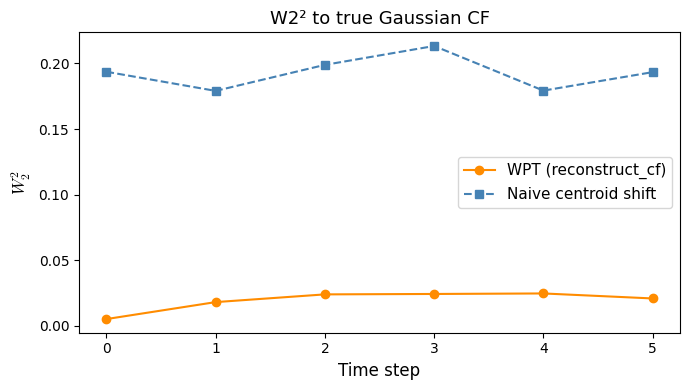

step       W2² WPT     W2² naive
--------------------------------
   0        0.0053        0.1936
   1        0.0182        0.1790
   2        0.0241        0.1988
   3        0.0244        0.2132
   4        0.0248        0.1792
   5        0.0210        0.1933


In [22]:
# Compute true CF with Gaussian Brenier map and compare W2 distances

# ── True CF: exact Gaussian parallel transport ────────────────────────────────
def sample_gaussian(mean, sigma, n=n_samples, seed=None):
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mean, sigma, size=n)

def empirical_w2(X, Y):
    """Empirical W2^2 via exact OT (uniform weights)."""
    import ot
    n, m = len(X), len(Y)
    a, b = np.ones(n) / n, np.ones(m) / m
    M = ot.dist(X, Y, metric='sqeuclidean')
    return float(ot.emd2(a, b, M))

# Fit Gaussians to control samples
ctrl_means  = [s.mean(axis=0) for s in control_samples]
ctrl_sigmas = [np.cov(s.T) for s in control_samples]

# Fit Gaussian to initial CF
cf_mean_cur  = cf_0.mean(axis=0)
cf_sigma_cur = np.cov(cf_0.T)

# Run true Gaussian PT step-by-step
true_cf_means  = [cf_mean_cur]
true_cf_sigmas = [cf_sigma_cur]

for i in range(n_steps):
    # Log map: control_i -> control_{i+1}
    A_ctrl, a_ctrl = log_map_gaussian(ctrl_means[i], ctrl_sigmas[i],
                                      ctrl_means[i+1], ctrl_sigmas[i+1])
    brenier_ctrl = BrenierGaussian(ctrl_means[i], ctrl_sigmas[i], A_ctrl, a_ctrl)

    # Log map: control_i -> cf_i  (geodesic for PT)
    A_geo, a_geo = log_map_gaussian(ctrl_means[i], ctrl_sigmas[i],
                                    cf_mean_cur, cf_sigma_cur)
    brenier_geo = BrenierGaussian(ctrl_means[i], ctrl_sigmas[i], A_geo, a_geo)

    # Parallel transport brenier_ctrl along brenier_geo
    transported_As, transported_as = brenier_ctrl.parallel_transport(brenier_geo, num_points=100)

    # Pushforward from cf_i using transported map
    brenier_transported = BrenierGaussian(cf_mean_cur, cf_sigma_cur,
                                          transported_As[-1], transported_as[-1])
    cf_mean_next, cf_sigma_next = brenier_transported.pushforward_measure(1)

    true_cf_means.append(cf_mean_next)
    true_cf_sigmas.append(cf_sigma_next)

    cf_mean_cur  = cf_mean_next
    cf_sigma_cur = cf_sigma_next

# ── Naive baseline: shift control centroids by fixed displacement at t=0 ──────
# displacement = cf centroid - control centroid at t=0
centroid_displacement = cf_0.mean(axis=0) - control_samples[0].mean(axis=0)
naive_samples = [control_samples[i] + centroid_displacement for i in range(n_steps + 1)]

# ── W2 distances vs true Gaussian CF ─────────────────────────────────────────
np.random.seed(0)
w2_wpt, w2_naive = [], []
for i in range(n_steps + 1):
    true_samples = sample_gaussian(true_cf_means[i], true_cf_sigmas[i], seed=i)
    w2_wpt.append(empirical_w2(cf_curve[i].locs, true_samples))
    w2_naive.append(empirical_w2(naive_samples[i], true_samples))

# ── Plot ──────────────────────────────────────────────────────────────────────
steps = np.arange(n_steps + 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, w2_wpt,   'o-',  color='darkorange', label='WPT (reconstruct_cf)')
ax.plot(steps, w2_naive, 's--', color='steelblue',  label='Naive centroid shift')
ax.set_xlabel('Time step', fontsize=12)
ax.set_ylabel(r'$W_2^2$', fontsize=12)
ax.set_title('W2² to true Gaussian CF', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(steps)
plt.tight_layout()
plt.show()

# ── Numerical summary ─────────────────────────────────────────────────────────
print(f"{'step':>4}  {'W2² WPT':>12}  {'W2² naive':>12}")
print('-' * 32)
for i in range(n_steps + 1):
    print(f"{i:>4}  {w2_wpt[i]:>12.4f}  {w2_naive[i]:>12.4f}")


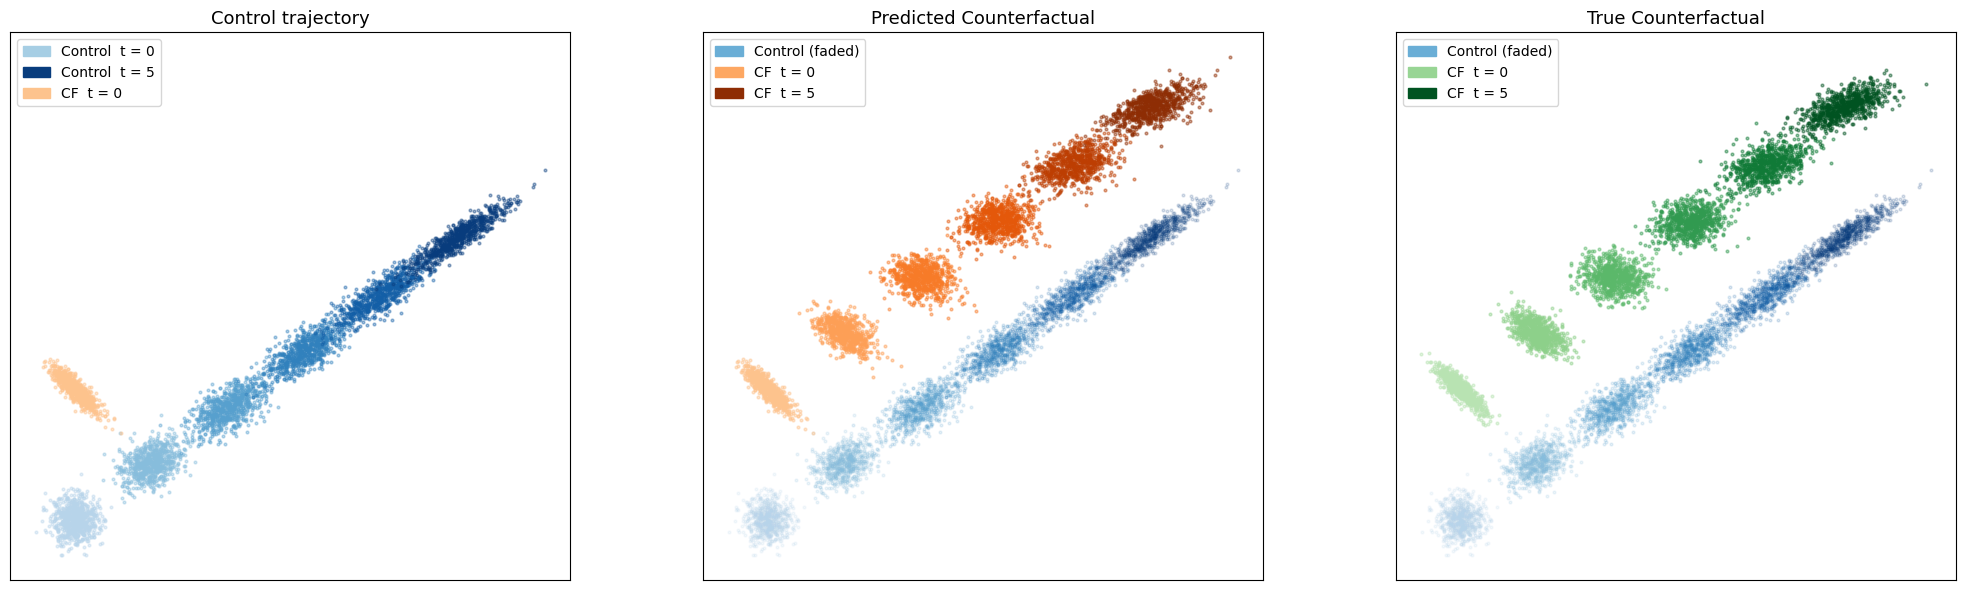

In [26]:
# ── Plot: control + empirical CF + true Gaussian CF ──────────────────────────
greens = cm.Greens

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)
for ax in axes:
    ax.set_aspect('equal')
    # get rid of ticks
    ax.set_xticks([])
    ax.set_yticks([])

# left: control trajectory
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[0].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.4, rasterized=True)
axes[0].scatter(cf_0[:, 0], cf_0[:, 1], color=oranges(0.3), s=4, alpha=0.45, rasterized=True)
axes[0].set_title('Control trajectory', fontsize=13)
axes[0].legend(handles=[
    Patch(color=blues(0.35),  label='Control  t = 0'),
    Patch(color=blues(0.95),  label=f'Control  t = {n_steps}'),
    Patch(color=oranges(0.3), label='CF  t = 0'),
], loc='upper left', fontsize=10)

# middle: empirical reconstruct_cf
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[1].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.15, rasterized=True)
for i, m in enumerate(cf_curve):
    c = oranges(0.3 + 0.65 * i / n_steps)
    axes[1].scatter(m.locs[:, 0], m.locs[:, 1], color=c, s=4, alpha=0.45, rasterized=True)
axes[1].set_title('Predicted Counterfactual', fontsize=13)
axes[1].legend(handles=[
    Patch(color=blues(0.5),    label='Control (faded)'),
    Patch(color=oranges(0.4),  label='CF  t = 0'),
    Patch(color=oranges(0.95), label=f'CF  t = {n_steps}'),
], loc='upper left', fontsize=10)

# right: true Gaussian CF (sample from each fitted Gaussian)
np.random.seed(1)
for i, s in enumerate(control_samples):
    c = blues(0.3 + 0.65 * i / n_steps)
    axes[2].scatter(s[:, 0], s[:, 1], color=c, s=4, alpha=0.15, rasterized=True)
for i, (mu, sigma) in enumerate(zip(true_cf_means, true_cf_sigmas)):
    c = greens(0.3 + 0.65 * i / n_steps)
    samp = np.random.multivariate_normal(mu, sigma, size=n_samples)
    axes[2].scatter(samp[:, 0], samp[:, 1], color=c, s=4, alpha=0.45, rasterized=True)
axes[2].set_title('True Counterfactual', fontsize=13)
axes[2].legend(handles=[
    Patch(color=blues(0.5),   label='Control (faded)'),
    Patch(color=greens(0.4),  label='CF  t = 0'),
    Patch(color=greens(0.95), label=f'CF  t = {n_steps}'),
], loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()
